## Affine-Partitioned Physics-Embedded Networks (AP-PEN) For Latent State Inference

Architecture:
- **Path net** `delta_hat_phi(t)` — Latent convenience yield.
- **`A(tau)` and `B(tau)`** — exponential-affine transform coefficients computed analtytically as they are detrministic
- **Fixed risk premium**: `alpha_Q` is no longer independently learned. It is DERIVED each step from `alpha_P - sigma2 * LAMBDA2_FIXED / kappa`, with `LAMBDA2_FIXED` (market price of convenience-yield risk) frozen at a "historical estimate" (data cell).
- **Parameter segregation**: `psi` splits into a Q-group `{kappa, sigma1, sigma2, rho}` (pricing) and a P-group `{alpha_P}` (real-world OU mean), each with its **own** optax `TrainState`, alongside the path net's. Three gradient steps per epoch (Calibration cell): Step 1 trains the path net on the full weighted loss with `psi` frozen; Step 2a trains Q via `e_data` only; Step 2b trains `alpha_P` via `e_sde` only (skipped if the variant has no `e_sde`). Separate `TrainState`s matter: a "frozen" group gets literally zero update, not zero instantaneous gradient fighting stale Adam momentum.
- **Pricing transform**: `F_hat = S * exp(B(tau) * delta_hat + A(tau))`.
- **Loss** = `e_data` (price MSE) + `e_sde` (OU transition NLL), WamOL-balanced. No `e_ode`: `A_coeff` is the exact ODE solution for any `psi`, so its residual is identically ~0 — no signal. `e_sde` never backprops into the path net (`error()` below) — letting it do so collapses `kappa` toward 0 and flattens `delta_hat`; that protection stays under the alternating scheme too.

In [1]:
import os
import sys
import types
import pickle
import time
from dataclasses import dataclass, asdict
from typing import Callable, Dict, Tuple, Union

import jax
import jax.numpy as jnp
from jax import jacrev, jit, lax, random, vmap
from jax.nn.initializers import glorot_normal, normal, zeros
from jax.flatten_util import ravel_pytree
from jax.tree_util import tree_leaves, tree_map

import optax
import ml_collections
from flax import linen as nn
from flax.training import train_state, orbax_utils
import orbax.checkpoint

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
print("JAX:", jax.__version__, "| x64 enabled:", jax.config.jax_enable_x64,
      "| default dtype:", jnp.ones(1).dtype)

JAX: 0.9.1 | x64 enabled: False | default dtype: float32


### Closed-form Gibson–Schwartz pricer

In [2]:
@dataclass(frozen=True)
class GSParams:
    """Risk-neutral GS Model 2 params. alpha_Q = alpha_P - sigma2*lambda2/kappa."""
    r: float
    kappa: float
    alpha_Q: float
    sigma1: float
    sigma2: float
    rho: float


def B_coeff(tau, kappa):
    return -(1.0 - jnp.exp(-kappa * tau)) / kappa


def A_coeff(tau, p: GSParams):
    kappa = p.kappa
    s1s2rho = p.sigma1 * p.sigma2 * p.rho
    s2sq = p.sigma2 ** 2

    lin = (p.r - p.alpha_Q + 0.5 * s2sq / kappa ** 2 - s1s2rho / kappa) * tau
    two_kappa = 0.25 * s2sq * (1.0 - jnp.exp(-2.0 * kappa * tau)) / kappa ** 3
    one_kappa = (p.alpha_Q * kappa + s1s2rho - s2sq / kappa) * (1.0 - jnp.exp(-kappa * tau)) / kappa ** 2
    return lin + two_kappa + one_kappa


# Pickle shim: mc_data.pkl stores GSParams by class path; resolve to the class above.
_gs_shim = types.ModuleType("gs_wamol.physics.gibson_schwartz")
_gs_shim.GSParams = GSParams
sys.modules.setdefault("gs_wamol", types.ModuleType("gs_wamol"))
sys.modules.setdefault("gs_wamol.physics", types.ModuleType("gs_wamol.physics"))
sys.modules["gs_wamol.physics.gibson_schwartz"] = _gs_shim

### Network Architecture

Generic `MLP` with optional weight-factorization reparameterisation on `Dense`.

In [3]:
activation_fn = {
    "tanh": jnp.tanh,
    "sin": jnp.sin,
}


def _get_activation(name):
    if name in activation_fn:
        return activation_fn[name]
    raise NotImplementedError(f"Activation {name} not in dictionary: {activation_fn.keys()}")


def _weight_fact(init_fn, mean, stddev):
    def init(key, shape):
        key1, key2 = random.split(key)
        w = init_fn(key1, shape)
        g = mean + normal(stddev)(key2, (shape[-1],))
        g = jnp.exp(g)
        v = w / g
        return g, v
    return init


class Dense(nn.Module):
    features: int
    kernel_init: Callable = glorot_normal()
    bias_init: Callable = zeros
    reparam: Union[None, Dict] = None

    @nn.compact
    def __call__(self, x):
        if self.reparam is None:
            kernel = self.param(
                "kernel", self.kernel_init, (x.shape[-1], self.features)
            )
        elif self.reparam["type"] == "weight_fact":
            g, v = self.param(
                "kernel",
                _weight_fact(
                    self.kernel_init,
                    mean=self.reparam["mean"],
                    stddev=self.reparam["stddev"],
                ),
                (x.shape[-1], self.features),
            )
            kernel = g * v
        bias = self.param("bias", self.bias_init, (self.features,))
        y = jnp.dot(x, kernel) + bias
        return y


class MLP(nn.Module):
    hidden_dim: Tuple[int] = (32, 16)
    out_dim: int = 1
    activation: str = "tanh"
    reparam: Union[None, Dict] = None

    def setup(self):
        self.activation_fn = _get_activation(self.activation)

    @nn.compact
    def __call__(self, x):
        for i in range(len(self.hidden_dim)):
            x = Dense(features=self.hidden_dim[i], reparam=self.reparam)(x)
            x = self.activation_fn(x)
        x = Dense(features=self.out_dim, reparam=self.reparam)(x)
        return x

### Build Network


In [4]:
def build_nets(config):
    reparam = None
    if config.ann_reparam:
        reparam = ml_collections.ConfigDict({"type": "weight_fact", "mean": 0.5, "stddev": 0.1})

    path_ann = MLP(hidden_dim=config.path_hidden_dim,
                   out_dim=1,
                   activation=config.ann_activation_str,
                   reparam=reparam)
    return path_ann


# psi = {kappa, sigma1, sigma2, rho, alpha_Q, alpha_P}; kappa/sigma2 are shared across
# Q/P (measure-invariant); softplus/tanh reparam keeps the optimiser unconstrained.
R_FIXED = 0.05 # risk free rate is a known input on WTI data


def _softplus_inv(y):
    return float(np.log(np.expm1(y)))


PSI_TRANSFORMS = {
    "kappa": (jax.nn.softplus, _softplus_inv), # mean-reversion speed - must be positive
    "sigma1": (jax.nn.softplus, _softplus_inv), # vol - must be positive
    "sigma2": (jax.nn.softplus, _softplus_inv), # vol - must be positive
    "rho": (jnp.tanh, lambda y: float(np.arctanh(y))), # correlation - must be in range (-1, 1)
    "alpha_P": (lambda x: x, lambda y: y), # no constraint on alpha_P, so identity transform
}


def constrain_psi(raw):
    """Apply transform from dict."""
    return {k: fwd(raw[k]) for k, (fwd, _) in PSI_TRANSFORMS.items()}


def constrain_psi_full(raw):
    psi = constrain_psi(raw)
    # analytically derived alpha_Q from learned alpha_P, sigma2, kappa (measure-change formula)
    # uses fixed LAMBDA2_FIXED defined in the data cell below; referenced here by name only,
    psi["alpha_Q"] = psi["alpha_P"] - psi["sigma2"] * LAMBDA2_FIXED / psi["kappa"]
    return psi


def raw_psi_init(psi0):
    # psi0: dict of desired *constrained* start values -> raw (unconstrained) leaf
    return {k: jnp.asarray(inv(psi0[k])) for k, (_, inv) in PSI_TRANSFORMS.items()}


def psi_to_gsparams(psi):
    # Effective Q pricing params + the P transition triple, all from learned psi.
    p_Q_eff = GSParams(
        r=R_FIXED, 
        kappa=psi["kappa"], 
        alpha_Q=psi["alpha_Q"],
        sigma1=psi["sigma1"], 
        sigma2=psi["sigma2"], 
        rho=psi["rho"])
    return {"p_Q": p_Q_eff, "kappa_P": psi["kappa"],
            "alpha_P": psi["alpha_P"], "sigma2_P": psi["sigma2"]}


def make_fns(path_ann, params):
    psi = constrain_psi_full(params["psi"])
    gsp = psi_to_gsparams(psi)
    p_Q_eff = gsp["p_Q"]

    # pricing transform: spot, analytic B(tau; learned kappa), state delta, analytic
    def log_F_hat_fn(S, delta, tau):
        return jnp.log(S) + B_coeff(tau, p_Q_eff.kappa) * delta + A_coeff(tau, p_Q_eff)

    def F_hat_fn(S, delta, tau):
        return jnp.exp(log_F_hat_fn(S, delta, tau))

    def delta_hat_fn(t):
        return path_ann.apply(params["path"], normalize_time(t))[0]

    return F_hat_fn, delta_hat_fn, gsp


# Q/P parameter segregation (architecture markdown) -- alpha_Q is deliberately
# absent from Q_KEYS: it's derived (constrain_psi_full), not an independent leaf.
Q_KEYS = ["kappa", "sigma1", "sigma2", "rho"]   # pricing / Q-measure
P_KEYS = ["alpha_P"]                             # real-world OU mean / P-measure


def split_psi(raw_psi):
    return {k: raw_psi[k] for k in Q_KEYS}, {k: raw_psi[k] for k in P_KEYS}


def merge_psi(q, p):
    return {**q, **p}


# path net + Q-psi + P-psi each get their own params (three separate TrainStates
# in calibration() below) -- returned separately rather than pre-merged into one
# param dict, unlike the earlier single-TrainState version of this notebook.
def init_nets(config, key):
    path_ann = build_nets(config)
    path_params0 = path_ann.init(key, jnp.ones((1,)))
    q0, p0 = split_psi(raw_psi_init(PSI_INIT))   # perturbed-from-truth init (see data cell)
    return path_ann, path_params0, q0, p0

### Optimiser

Core code inherited from https://github.com/khoshisashi/AC-PINNs/blob/main/AC_PINNs_IVS_calibration.ipynb for the original SABR / Dupire-local-vol problem by Khoshisashi et al. 2023. in his ACPINN repo.

In [5]:
import json

with open("../config/hp.sweep.json", "r") as f:
    adam_hp = json.load(f)

# adam with exponential LR decay: large steps early, smaller as it settles near a minimum
def make_optimizer(hp):
    lr = optax.exponential_decay(
        init_value=hp["learning_rate"], 
        transition_steps=hp["decay_steps"],
        decay_rate=hp["decay_rate"],
    )
    return optax.adam(
        learning_rate=lr, b1=hp["beta1"], b2=hp["beta2"], eps=hp["adam_eps"]
    )

### Input Data

Monte Carlo simulated data generated by `monte_carlo.ipynb` and saved to `data/gs_mc_data.npz`.

Split across the next two cells so the source is swappable: the first builds `data`/`taus`/`normalize_time` (all `calibration`/`error` consume — a real-WTI loader is a drop-in here); the second holds `delta_true`/`PSI_TRUE`, MC-only ground truth with no real-data equivalent.

In [6]:
import pandas as pd

_MC_DATA_PATH = "../data/input/synthetic/mc_data.pkl"
_WTI_DATA_PATH = "../data/input/real/wti_analysis_ready.csv"

def get_data_mc(path_id=0, path=_MC_DATA_PATH):
    """MC loader: bundles generic (t, S, taus, log_F_obs) with MC-only ground truth."""
    with open(path, "rb") as f:
        mc_data = pickle.load(f)

    taus = mc_data["taus"]
    t_train = mc_data["t_grid"]
    S_train = mc_data["S"][path_id]
    log_F_obs_train = mc_data["log_F_obs"][path_id]

    delta_true = mc_data["delta_true"][path_id] # eval target

    p_Q = GSParams(**asdict(mc_data["params_Q"]))
    kappa_P = mc_data["params_P"]["kappa"]
    alpha_P = mc_data["params_P"]["alpha_P"]
    sigma2_P = mc_data["params_P"]["sigma2"]

    return (t_train, S_train, taus, log_F_obs_train, delta_true, p_Q, kappa_P, alpha_P,
            sigma2_P)

def get_data_wti(path=_WTI_DATA_PATH, n_maturities=8):
    """WTI loader: long (date x contract) panel -> rectangular (dates x n_maturities).

    Ranks each date's live contracts by tau ascending into maturity slots
    0..n_maturities-1, keeping only dates with >= n_maturities contracts
    (n_maturities=8 keeps ~96% of dates -- 8 is the modal contract count;
    the rest have 6-7 and are dropped). `taus` is the per-slot MEAN tau across
    all kept dates -- a static stand-in for what is actually a per-date
    shrinking tau. error() only accepts one shared taus vector today; feeding
    it the true per-date tau matrix instead of this mean requires updating
    error() itself, which hasn't been done yet.
    """
    df = pd.read_csv(path)
    df = df.dropna(subset=["spot", "rate"])  # drops 2020-04-20 (negative-price day)
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["date", "tau"])
    df["slot"] = df.groupby("date").cumcount()
    df = df[df["slot"] < n_maturities]
    df = df[df.groupby("date")["slot"].transform("count") == n_maturities]

    tau_matrix = df.pivot(index="date", columns="slot", values="tau").sort_index()
    settle_matrix = df.pivot(index="date", columns="slot", values="settle").sort_index()
    spot_by_date = df.groupby("date")["spot"].first().sort_index()
    rate_by_date = df.groupby("date")["rate"].first().sort_index()

    dates = tau_matrix.index.to_numpy()
    t_train = ((dates - dates[0]) / np.timedelta64(365, "D")).astype(float)
    S_train = spot_by_date.to_numpy()
    taus = tau_matrix.to_numpy().mean(axis=0)
    log_F_obs_train = np.log(settle_matrix.to_numpy())
    r_train = rate_by_date.to_numpy()

    delta_true = p_Q = kappa_P = alpha_P = sigma2_P = None  # no ground truth for real data

    return (dates, t_train, S_train, taus, log_F_obs_train, delta_true, p_Q, kappa_P, alpha_P,
            sigma2_P, r_train)


In [7]:
t_train, S_train, taus, log_F_obs_train, delta_true, p_Q, kappa_P, alpha_P, sigma2_P = get_data_mc(path_id=0)

# data/taus/normalize_time are ALL that calibration()/error() consume -- source-agnostic
data = (t_train, S_train, log_F_obs_train)


T_SCALE = float(t_train[-1])


def normalize_time(t):
    return jnp.atleast_1d(t / T_SCALE)


print("t_train        ", t_train.shape, f"[{float(t_train.min()):.2f}, {float(t_train.max()):.2f}]")
print("S_train        ", S_train.shape, f"[{float(S_train.min()):.2f}, {float(S_train.max()):.2f}]")
print("taus           ", taus.shape, f"[{float(taus.min()):.3f}, {float(taus.max()):.3f}]")
print("log_F_obs_train", log_F_obs_train.shape, "(dates x maturities)")


t_train         (1001,) [0.00, 10.00]
S_train         (1001,) [35.89, 165.12]
taus            (12,) [0.083, 1.000]
log_F_obs_train (1001, 12) (dates x maturities)
is_crisis       (1001,) 0 crisis-flagged rows (0 expected for MC data)


In [8]:
# MC-only ground truth: real data has no delta_true/PSI_TRUE (delta_t is latent in reality).
# PSI_INIT is perturbed FROM PSI_TRUE (~30-50% off) so training is a recovery test, not
# stability check; a real-data run would need PSI_INIT set independently instead.
def psi_dict(p_Q, alpha_P):
    """GSParams + alpha_P -> the canonical 6-key psi dict (shared by PSI_TRUE here
    and by the recovered psi_hat in the path-repeat validation cell)."""
    return {
        "kappa":   float(p_Q.kappa),
        "sigma1":  float(p_Q.sigma1),
        "sigma2":  float(p_Q.sigma2),
        "rho":     float(p_Q.rho),
        "alpha_Q": float(p_Q.alpha_Q),
        "alpha_P": float(alpha_P),
    }


PSI_TRUE = psi_dict(p_Q, alpha_P)
PSI_INIT = {
    "kappa":   PSI_TRUE["kappa"]  * 1.5,
    "sigma1":  PSI_TRUE["sigma1"] * 0.7,
    "sigma2":  PSI_TRUE["sigma2"] * 1.3,
    "rho":     PSI_TRUE["rho"]    * 0.6,
    "alpha_Q": PSI_TRUE["alpha_Q"] + 0.06,   # unused as an init -- alpha_Q is derived, not
                                              # learned (see below); kept so PSI_INIT still has
                                              # all 6 keys for the recovery tables/plots.
    "alpha_P": PSI_TRUE["alpha_P"] - 0.06,
}

# Fixed risk premium (architecture markdown): lambda2 = kappa*(alpha_P - alpha_Q)/sigma2
# is frozen at a "historical estimate" rather than learned, and alpha_Q is derived from
# it (constrain_psi_full) instead of being an independent psi leaf. There is no Kalman/
# historical-fit pipeline wired into this notebook yet, so LAMBDA2_FIXED is deliberately
# NOT the true simulator value (that would be an oracle test) -- it's perturbed +30% off
# LAMBDA2_TRUE, matching this cell's existing perturb-from-truth philosophy for PSI_INIT.
# A standalone robustness sweep (+-30% lambda2 error) confirmed the sigma1/sigma2/rho
# identifiability gain isn't oracle-only -- see docs/project_summary.md.
LAMBDA2_TRUE = float(PSI_TRUE["kappa"] * (PSI_TRUE["alpha_P"] - PSI_TRUE["alpha_Q"]) / PSI_TRUE["sigma2"])
LAMBDA2_FIXED = LAMBDA2_TRUE * 1.30

print("delta_true     ", delta_true.shape, "HELD OUT -- evaluation only")
print("PSI_TRUE       ", {k: round(v, 4) for k, v in PSI_TRUE.items()})
print("PSI_INIT       ", {k: round(v, 4) for k, v in PSI_INIT.items()}, "(learned from here)")
print("LAMBDA2_TRUE   ", round(LAMBDA2_TRUE, 4), " LAMBDA2_FIXED (used) ", round(LAMBDA2_FIXED, 4))

delta_true      (1001,) HELD OUT -- evaluation only
PSI_TRUE        {'kappa': 1.876, 'sigma1': 0.393, 'sigma2': 0.527, 'rho': 0.766, 'alpha_Q': 0.0779, 'alpha_P': 0.106}
PSI_INIT        {'kappa': 2.814, 'sigma1': 0.2751, 'sigma2': 0.6851, 'rho': 0.4596, 'alpha_Q': 0.1379, 'alpha_P': 0.046} (learned from here)
LAMBDA2_TRUE    0.1  LAMBDA2_FIXED (used)  0.13


### Loss terms — `error()`

Rewritten to match the attached architecture diagram (analytic `A(tau)`/`B(tau)` + WamOL-balanced loss channels), replacing the earlier terms from `docs/mathematical_derivations-5.pdf`. Unchanged by the fixed-risk-premium/parameter-segregation rework above — `error()` just consumes whatever `psi` `make_fns` hands it, and doesn't care whether `alpha_Q` inside that `psi` was learned or derived.

- `e_data` = the diagram's $\hat{\mathcal{L}}_{\text{data}}$ — data misfit in log-price space (was `e_acc`)
- `e_ode` — **not applicable in this variant.** `A(tau)` is now the exact closed-form `A_coeff`, which satisfies its defining ODE identically for any `psi`; there is no learned `A_hat` left to regularise, so the channel is dropped rather than kept as a permanent zero.
- `e_sde` = the diagram's $\hat{\mathcal{L}}_{\text{SDE}}$ — OU transition-density residual on the recovered path
- `e_cac`/`e_rcac` = `mathematical_derivations-6.pdf` §7.1-7.2 — cash-and-carry ceiling / reverse-cash-and-carry floor, hinge-squared, evaluated on the data manifold `(S_i, delta_hat(t_i), tau_i)`. `STORAGE_COST_U`/`DELTA_MAX` are single literature-grounded constants (loss-terms constants cell). An earlier version made them time-varying via a crisis-date regime switch (motivated by a model-free check: a fixed `u=0.10` is violated on 63%/47%/21% of 2015/2016/2020 rows vs 0-2% elsewhere) — scrapped after a 10k/40k-epoch ablation (AP-PEN (ARB) vs the Kalman filter, real WTI) found no measurable difference in `delta_hat`'s fit to Kalman between the regime-switched and constant-bound variants at full convergence. The single constant kept is the *crisis*-level value, not the baseline one — see the constants cell for why.
- `e_delta_floor` = `mathematical_derivations-6.pdf` §7.3, eq. 38 — convenience-yield floor, hinge-squared directly on the latent path `delta_hat(t_i)` at observation times (no price/maturity dependence, unlike `e_cac`/`e_rcac`). Implemented (`APPINN_ARB` only, alongside `e_cac`/`e_rcac`); `DELTA_MIN=-0.3` per eq. 39 — an empirical guardrail, deliberately *not* the Liu & Tang (2010) no-arbitrage floor of exactly 0 (see the constant's comment in the cell below for why a hard structural floor there would bias the inversion). Kept as a single constant, not time-varying like `u`/`delta_max` above — no lit-review figure to anchor a crisis-regime value to.
- $\mathcal{L}_b$ (initial-condition loss) remains **not implemented** — `A(0)=0`/`F(S,delta,0)=S` already hold identically here since `A_coeff`/`B_coeff` are the closed-form solution, not a learned surface, so there's nothing for it to enforce in this architecture (unlike the PDE-residual notebook that boundary condition targets).

In [9]:
# Literature-grounded no-arbitrage guardrails (docs/mathematical_derivations-6.pdf S7) --
# deliberately LOOSE outer bounds, not tight estimates. Originally implemented as a
# time-varying regime step function keyed on a crisis-date flag (widening U/DELTA_MAX on
# 2015-2016 and Apr-2020 dates, since a fixed u=0.10 ceiling is violated on 63%/47%/21%
# of those years' rows vs 0-2% elsewhere). Scrapped back to a single constant after an
# ablation (AP-PEN (ARB) vs the Kalman filter, real WTI, 10/10k/40k-epoch runs at fixed
# seed) found no measurable difference in delta_hat's fit to Kalman between the
# regime-switched and constant-bound variants at full (40k) convergence -- the switch
# wasn't earning its complexity. The single constant kept below is deliberately the
# CRISIS-level value, not the baseline one: it's the one already proven not to
# spuriously bind anywhere in the sample (see comment), so reverting to baseline would
# reintroduce the exact "violated 63%/47%/21% of crisis rows" problem the switch existed
# to fix in the first place.
U_LEVEL = 0.30              # per-annum storage cost. CME LOOP storage futures spiked to
                             # $0.55/bbl/month in Apr 2020; against a representative
                             # (pre-crash) spot of $30-50/bbl that's ~13-22%/yr -- 0.30
                             # sits generously above that conversion. Also safely above
                             # Stancu et al. 2022's baseline-era average (~6%/yr, ~9%/yr
                             # in contango), so it doesn't spuriously bind in ordinary
                             # contango either -- one constant, safe in both regimes.
DELTA_MAX_LEVEL = 0.75      # rcac wedge: Gibson & Schwartz (1990) Table VI realized
                             # instantaneous annualized convenience yield +65.5% (23 May
                             # 1989), Figure 2 excursions toward ~100% in turmoil,
                             # long-run mean only ~18-25%/yr -- 0.75 sits in the
                             # literature-consistent 0.60-1.0 tail-ceiling band. Checked
                             # directly against real WTI data: NEVER binds at 0.75
                             # across the full 2015-2026 sample, crisis years included --
                             # no crisis widening needed here at all.
DELTA_MIN = -0.3            # convenience-yield floor (S7.3, eq. 39): NOT the Liu & Tang
                             # (2010) no-arbitrage floor of exactly 0 -- that paper proves
                             # delta>=0 under idealized costless-storage no-arbitrage, but
                             # a hard structural floor at 0 would fight the OU dynamics'
                             # Gaussian marginals and bias delta_hat upward in exactly the
                             # deep-contango regime this model exists to capture (e.g. the
                             # Apr-2020 negative-WTI episode implies a sharply negative
                             # realized convenience yield). Set instead to the empirical
                             # lower edge of delta_true across the MC-simulated paths,
                             # mirroring how DELTA_MAX_LEVEL was tuned.

def guardrail_arrays(n):
    """Broadcast the single literature-grounded U_LEVEL/DELTA_MAX_LEVEL to a per-date
    (n,) array -- kept as arrays (not scalars) only so error()'s existing
    STORAGE_COST_U[:, None]/DELTA_MAX[:, None] broadcasting doesn't need to change."""
    return jnp.full((n,), U_LEVEL), jnp.full((n,), DELTA_MAX_LEVEL)


STORAGE_COST_U, DELTA_MAX = guardrail_arrays(len(t_train))


def error(fns, data):
    F_hat_fn, delta_hat_fn, gsp = fns
    # gsp holds the learned (not true) effective Q params + P transition triple
    p_Q = gsp["p_Q"]
    kappa_P = gsp["kappa_P"]
    alpha_P = gsp["alpha_P"]
    sigma2_P = gsp["sigma2_P"]
    t_train, S_train, log_F_obs_train = data

    # Latent path at observation times. Input is t alone (S6 remark 1).
    delta_hat = vmap(delta_hat_fn)(t_train)                          # (n,)

    def log_F_hat_fn(S, delta, tau):
        return jnp.log(S) + B_coeff(tau, p_Q.kappa) * delta + A_coeff(tau, p_Q)

    log_F_hat = vmap(
        lambda S, d: vmap(lambda tau: log_F_hat_fn(S, d, tau))(taus)
    )(S_train, delta_hat)                                            # (n, K)
    e_data = (log_F_hat - log_F_obs_train) ** 2                       # (n, K)

    dt = jnp.diff(t_train)                                            # (n-1,)

    # e_sde trains ONLY alpha_P: kappa/sigma2 are already identified by the pricing
    # channels, and an OU-MLE on the smoothed NN path is degenerate for them (drives
    # kappa->0). kappa_P/sigma2_P and the path itself are stop-gradiented here.
    kappa_P_sde = lax.stop_gradient(kappa_P)
    sigma2_P_sde = lax.stop_gradient(sigma2_P)

    def sde_nll(delta_i, delta_ip1, dt_i):
        mean = alpha_P + (delta_i - alpha_P) * jnp.exp(-kappa_P_sde * dt_i)
        var = (sigma2_P_sde ** 2 / (2.0 * kappa_P_sde)) * (1.0 - jnp.exp(-2.0 * kappa_P_sde * dt_i))
        return 0.5 * jnp.log(2.0 * jnp.pi * var) + 0.5 * (delta_ip1 - mean) ** 2 / var

    delta_hat_sde = lax.stop_gradient(delta_hat)
    e_sde = vmap(sde_nll)(delta_hat_sde[:-1], delta_hat_sde[1:], dt)  # (n-1,)

    # No-arb hinges (deriv-6 S7.1-7.2), on the data manifold -- same (n,K) grid as e_data,
    # reusing F_hat = exp(log_F_hat). cac ceiling excludes delta (S7.1); rcac floor carries
    # the delta_max wedge (S7.2). Hinge squared is C1 through the kink (eq. 49 remark).
    # STORAGE_COST_U/DELTA_MAX are (n,) arrays -- [:, None] broadcasts the same
    # constant across each date's K maturities.
    F_hat_grid = jnp.exp(log_F_hat)                                    # (n, K)
    ceiling = S_train[:, None] * jnp.exp((p_Q.r + STORAGE_COST_U[:, None]) * taus[None, :])
    rcac_floor = S_train[:, None] * jnp.exp((p_Q.r - DELTA_MAX[:, None]) * taus[None, :])
    e_cac = jnp.maximum(0., F_hat_grid - ceiling) ** 2                 # (n, K)
    e_rcac = jnp.maximum(0., rcac_floor - F_hat_grid) ** 2             # (n, K)

    # Convenience-yield floor (S7.3, eq. 38/40) -- unlike cac/rcac, this acts directly on
    # the latent path at observation times, not on the (S, tau) data manifold: it has no
    # dependence on price level at all (dimension time^-1 on both sides of the hinge).
    e_delta_floor = jnp.maximum(0., DELTA_MIN - delta_hat) ** 2                     # (n,)

    err = {
        "e_data": e_data,
        "e_sde": e_sde,
        "e_cac": e_cac,
        "e_rcac": e_rcac,
        "e_delta_floor": e_delta_floor,
    }
    metrics = {k: jnp.mean(v) for k, v in err.items()}
    return err, metrics


In [10]:
def adj(loss, lw):
    return lw * jnp.mean(loss)


def make_loss_lb(components):
    def loss_fn(fns, data, l_ws):
        err, metrics = error(fns, data)
        loss = {k: adj(err[k], l_ws[k]) for k in components}
        return loss, metrics
    return loss_fn


def make_loss_fn(components):
    def loss_fn(fns, data, l_ws):
        loss, metrics = loss_fn_lb[components](fns, data, l_ws)
        return sum(loss.values()), metrics
    return loss_fn


# single source of truth for which loss channels each variant trains on --
# init_l_ws (below) derives its channel sets from this too, instead of being a
# second, independently-typed list that has to be kept in sync by hand.
# No "PINN" (e_data + e_ode) tier in this variant: A(tau) is analytic, so there is
# no learned drift net for an ODE residual to discipline (see architecture markdown).
VARIANT_COMPONENTS = {
    "MLP": ["e_data"],                                    # data-misfit only
    "APPINN": ["e_data", "e_sde"],                         # full AP-PEN architecture
    "APPINN_ARB": ["e_data", "e_sde", "e_cac", "e_rcac", "e_delta_floor"],  # + no-arb hinges
}

loss_fn_lb = {k: make_loss_lb(v) for k, v in VARIANT_COMPONENTS.items()}
loss_fn = {k: make_loss_fn(k) for k in loss_fn_lb}

### Calibration

Three separate `TrainState`s (path net, Q-psi, P-psi=`alpha_P`), each updated by its own gradient step per epoch (Step 1 / Step 2a / Step 2b — architecture markdown), rather than one joint step over a shared param pytree. WamOL gradient-norm balancing now applies only within Step 1 (`l_ws` for `e_data`/`e_sde`/`e_cac`/`e_rcac`, all of which only ever train the path net there) — Steps 2a/2b are each single-channel objectives with nothing to balance. Checkpointing unchanged. The per-point ("piecewise") self-adaptive weight optimizer from the original AC-PINN code (`params_sa`, SGD ascent) is removed -- only the component-level balancing is kept.

In [11]:
def flatten_pytree(pytree):
    return ravel_pytree(pytree)[0]

# initial per-channel loss weights, derived from the same VARIANT_COMPONENTS
# that defines loss_fn_lb (cell above) -- one source of truth for "which
# channels does each variant train."
init_l_ws = {k: {c: 1. for c in v} for k, v in VARIANT_COMPONENTS.items()}

# Own output dir, NOT the archived dual-network notebook's (notebooks/archive/AP-PINN
# dual network.ipynb) data/output/mc_simulated/ --
# that directory is keyed only by loss_str (run_tag), with no per-notebook
# namespacing, so writing here would silently clobber that archived notebook's
# checkpoints/results the next time either notebook runs (this happened during
# development -- a smoke test overwrote real results). Kept alongside it under
# data/output/, which is gitignored/disposable either way.
_MC_OUTPUT_DIR = "../data/output/mc_simulated_single_net"

# training loop -- parameter segregation (architecture markdown): 3 separate
# TrainStates (path net, Q-psi, P-psi), 3 separate gradient steps per epoch.
def calibration(config, data, hp=adam_hp, save_checkpoint=True):
    ofunc = loss_fn[config.loss_str]
    components = VARIANT_COMPONENTS[config.loss_str]
    has_sde = "e_sde" in components
    l_ws = dict(init_l_ws[config.loss_str])

    key = random.PRNGKey(config.seed)
    key, key_init = random.split(key, 2)

    path_ann, path_params0, q0, p0 = init_nets(config, key_init)
    state_path = train_state.TrainState.create(apply_fn=None, params=path_params0, tx=make_optimizer(hp))
    state_q = train_state.TrainState.create(apply_fn=None, params=q0, tx=make_optimizer(hp))
    state_p = train_state.TrainState.create(apply_fn=None, params=p0, tx=make_optimizer(hp))

    def assemble(path_p, q_p, p_p):
        return {"path": path_p, "psi": merge_psi(q_p, p_p)}

    # Step 1: psi (both groups) frozen -- passed in as plain (non-differentiated)
    # values, not just stop-gradiented, since only path_p is the grad target here.
    # Trains on the variant's full weighted loss, same channels/l_ws as before.
    @jit
    def step1(state_path, q_p, p_p, l_ws):
        def loss_fn_(path_p):
            fns = make_fns(path_ann, assemble(path_p, q_p, p_p))
            return ofunc(fns, data, l_ws)
        (loss, metric), grads = jax.value_and_grad(loss_fn_, has_aux=True)(state_path.params)
        return state_path.apply_gradients(grads=grads), loss, metric

    # Step 2a: path net + P-psi frozen. Q-psi trained via e_data only -- this is
    # the "MSE loss only updates the Q-parameters" routing from the architecture
    # markdown; e_cac/e_rcac (APPINN_ARB) deliberately excluded here even though
    # they also depend on Q-psi, to keep this step a clean single-channel MLE.
    @jit
    def step2a(state_q, path_p, p_p):
        def loss_fn_(q_p):
            fns = make_fns(path_ann, assemble(path_p, q_p, p_p))
            err, _ = error(fns, data)
            return jnp.mean(err["e_data"])
        loss, grads = jax.value_and_grad(loss_fn_)(state_q.params)
        return state_q.apply_gradients(grads=grads)

    # Step 2b: path net + Q-psi frozen. alpha_P trained via e_sde only. Skipped
    # entirely when the variant has no e_sde channel (MLP) -- alpha_P then stays
    # at its init value, same as the earlier single-TrainState version.
    @jit
    def step2b(state_p, path_p, q_p):
        def loss_fn_(p_p):
            fns = make_fns(path_ann, assemble(path_p, q_p, p_p))
            err, _ = error(fns, data)
            return jnp.mean(err["e_sde"])
        loss, grads = jax.value_and_grad(loss_fn_)(state_p.params)
        return state_p.apply_gradients(grads=grads)

    hist_loss = []
    momentum = config.loss_balancing_momentum
    start_time = time.time()

    # Grad-norm balancing (S12.2, eq. 55-56) now only ever needs path_p's norm --
    # Step 1 is the only step combining multiple weighted channels, and it only
    # ever differentiates w.r.t. the path net (psi is fully frozen there). No more
    # COMPONENT_SUPPORT/FULL_SUPPORT: with 3 separate TrainStates there's no
    # shared pytree to select a support subset out of.
    @jit
    def update_loss_weights(state_path, q_p, p_p, l_ws):
        def loss_fn_(path_p):
            fns = make_fns(path_ann, assemble(path_p, q_p, p_p))
            err, _ = error(fns, data)
            return {c: jnp.mean(err[c]) for c in components}
        grads = jacrev(loss_fn_)(state_path.params)
        grad_norm_dict = {c: jnp.abs(flatten_pytree(grads[c])).mean() for c in components}
        sum_grad_norm = jnp.sum(jnp.stack(tree_leaves(grad_norm_dict)))
        w = tree_map(lambda x: jnp.where(x == 0., 1., sum_grad_norm / x), grad_norm_dict)
        weights = tree_map(lambda old_w, new_w: old_w * momentum + (1 - momentum) * new_w, l_ws, w)
        return lax.stop_gradient(weights)

    # Training loop
    print(f"{config.loss_str} calibration------>")
    # Only the two full AP-PEN variants carry more than one loss channel and ever run
    # the balancer; balancing=False runs with fixed lambda=1 as a control.
    use_balancing = config.get("balancing", True) and config.loss_str in ("APPINN", "APPINN_ARB")
    for epoch in range(config.num_epochs):

        if use_balancing and epoch % 100 == 0:
            l_ws = update_loss_weights(state_path, state_q.params, state_p.params, l_ws)

        state_path, loss, metric = step1(state_path, state_q.params, state_p.params, l_ws)
        state_q = step2a(state_q, state_path.params, state_p.params)
        if has_sde:
            state_p = step2b(state_p, state_path.params, state_q.params)

        # float(...) forces a device->host sync every epoch (needed for full-resolution curve);
        # done here once per channel, not deferred to plot time against a pickled JAX array.
        metric_snap = {k: float(v) for k, v in metric.items()}
        psi_snap = {k: float(v) for k, v in constrain_psi_full(merge_psi(state_q.params, state_p.params)).items()}
        hist_loss.append((epoch, float(loss), metric_snap, psi_snap))
        if (epoch % 1000) == 0:
            print(f"Epoch {epoch}: loss = {loss:.6f}", end="\r")

    comp_time = time.time() - start_time
    print(f"------> completed in {comp_time:.2f} seconds")

    # save_checkpoint=False for the path-repeat loop: run_tag(config) is the SAME
    # "APPINN" dir the main single-path run already wrote to, so 20 repeat calls
    # saving here would silently clobber that run's checkpoint with the last
    # path's weights (this actually happened -- see docs/project_summary.md).
    if save_checkpoint:
        CKPT_DIR = os.path.abspath(f'{_MC_OUTPUT_DIR}/checkpoints/{run_tag(config)}')
        ckpt = {'params': {"path": state_path.params, "psi_q": state_q.params, "psi_p": state_p.params}, 'ls': l_ws}
        orbax_checkpointer = orbax.checkpoint.PyTreeCheckpointer()
        save_args = orbax_utils.save_args_from_target(ckpt)
        orbax_checkpointer.save(CKPT_DIR, ckpt, force=True, save_args=save_args)

    final_params = assemble(state_path.params, state_q.params, state_p.params)
    return make_fns(path_ann, final_params), hist_loss

def run_tag(config):
    """File-safe tag: loss_str, with a `_nobal` suffix whenever balancing is off
    (not special-cased to one variant -- applies to any config with a balancing flag)."""
    suffix = "" if config.get("balancing", True) else "_nobal"
    return f"{config.loss_str}{suffix}"


def run_experiment(config, data, hp=adam_hp):
    fns, hist_loss = calibration(config, data, hp)

    results = {'config': config, 'history': hist_loss, 'adam_hp': dict(hp)}
    os.makedirs(f'{_MC_OUTPUT_DIR}/results', exist_ok=True)
    with open(f'{_MC_OUTPUT_DIR}/results/results_{run_tag(config)}.pkl', 'wb') as f:
        pickle.dump(results, f)

    return fns


def make_variant_configs(num_epochs=5000, path_hidden_dim=(32, 32, 32), seed=42):
    """One MLP/APPINN_nobal/APPINN/APPINN_ARB config quartet -- shared by the MC run,
    the real-WTI run, and the temporal-holdout run below, instead of retyping the same
    hyperparameter dict three times with only loss_str/balancing ever differing."""
    base = ml_collections.ConfigDict({
        "loss_str": "MLP",
        "num_epochs": num_epochs,
        "path_hidden_dim": path_hidden_dim,
        "ann_activation_str": "tanh",
        "loss_balancing_momentum": 0.5,
        "seed": seed,
        "ann_reparam": False,
        "balancing": True,     # WamOL whack-a-mole on by default (AP-PEN variants only)
    })
    appinn = ml_collections.ConfigDict(base.to_dict())
    appinn.loss_str = "APPINN"
    # CONTROL: AP-PEN with the WamOL balancer OFF -- isolates whether the balancer drives any path collapse.
    appinn_nobal = ml_collections.ConfigDict(appinn.to_dict())
    appinn_nobal.balancing = False
    # AP-PEN + no-arbitrage hinge penalties (e_cac, e_rcac, e_delta_floor), balancing on.
    appinn_arb = ml_collections.ConfigDict(appinn.to_dict())
    appinn_arb.loss_str = "APPINN_ARB"
    return base, appinn_nobal, appinn, appinn_arb

### Run

Four variants run each time: `MLP` (data-misfit only), `AP-PEN` no-bal (`APPINN_nobal` — fixed `lambda=1`), `AP-PEN` (full architecture, WamOL balancing on), and `AP-PEN` with no-arb constraints (`APPINN_ARB` — adds `e_cac`/`e_rcac`/`e_delta_floor`, balancing on). No `PINN` tier here (see architecture markdown) — with `A(tau)` analytic there is no drift net for an ODE residual to train. `num_epochs=40000` here (matching the archived dual-network notebook's scale) so `psi` and the loss channels are trained to full convergence, not just moved meaningfully; results/checkpoints go to this notebook's own `data/output/mc_simulated_single_net/`, not the archived dual-network notebook's directory.

In [12]:
config_MLP, config_APPINN_nobal, config_APPINN, config_APPINN_ARB = make_variant_configs(num_epochs=40000)

# psi is a learned leaf in every run; train all four at 40k for full convergence.
fns_MLP = run_experiment(config_MLP, data)
fns_APPINN_nobal = run_experiment(config_APPINN_nobal, data)
fns_APPINN = run_experiment(config_APPINN, data)
fns_APPINN_ARB = run_experiment(config_APPINN_ARB, data)

# single source of truth for the 4-variant roster -- every downstream eval/plot cell
# iterates this instead of re-listing the same (fns, config) pairing each time.
configs = [config_MLP, config_APPINN_nobal, config_APPINN, config_APPINN_ARB]
fns_by_tag = {
    run_tag(config_MLP): fns_MLP,
    run_tag(config_APPINN_nobal): fns_APPINN_nobal,
    run_tag(config_APPINN): fns_APPINN,
    run_tag(config_APPINN_ARB): fns_APPINN_ARB,
}

W0802 09:58:55.686621 31592681 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


MLP calibration------>


------> completed in 33.68 seconds
APPINN calibration------>


------> completed in 41.80 seconds
APPINN calibration------>


------> completed in 43.80 seconds
APPINN_ARB calibration------>


------> completed in 48.31 seconds


In [13]:
# compute once per model, reused by this cell and the two eval cells below
eval_by_tag = {}
for tag, fns in fns_by_tag.items():
    _, delta_hat_fn, _ = fns
    err, metrics = error(fns, data)
    eval_by_tag[tag] = {"metrics": metrics, "delta_hat": vmap(delta_hat_fn)(t_train)}

for tag, ev in eval_by_tag.items():
    print(f"Metrics for {tag}:")
    for k, v in ev["metrics"].items():
        print(f"  {k}: {v:.6e}")

Metrics for MLP:
  e_data: 4.697439e-04
  e_sde: -2.025216e+00
  e_cac: 1.810609e-01
  e_rcac: 0.000000e+00
  e_delta_floor: 2.222677e-04
Metrics for APPINN_nobal:
  e_data: 3.977158e-04
  e_sde: -1.987826e+00
  e_cac: 1.657084e-01
  e_rcac: 0.000000e+00
  e_delta_floor: 1.526948e-04
Metrics for APPINN:
  e_data: 3.977158e-04
  e_sde: -1.987826e+00
  e_cac: 1.657084e-01
  e_rcac: 0.000000e+00
  e_delta_floor: 1.526948e-04
Metrics for APPINN_ARB:
  e_data: 6.464505e-04
  e_sde: -3.066578e+00
  e_cac: 1.315770e-09
  e_rcac: 0.000000e+00
  e_delta_floor: 0.000000e+00


### Model Evals (MC-simulated data only — scores against `delta_true`/`PSI_TRUE`, no real-WTI equivalent)

In [14]:
def sde_nll(delta_i, delta_ip1, dt_i, kappa, alpha, sigma):
    mean = alpha + (delta_i - alpha) * jnp.exp(-kappa * dt_i)
    var  = (sigma**2 / (2.0*kappa)) * (1.0 - jnp.exp(-2.0*kappa*dt_i))
    return 0.5*jnp.log(2.0*jnp.pi*var) + 0.5*(delta_ip1 - mean)**2 / var

def sde_floor(dt, kappa, sigma):
    var = (sigma**2 / (2.0*kappa)) * (1.0 - jnp.exp(-2.0*kappa*dt))
    return jnp.mean(0.5*jnp.log(2.0*jnp.pi*var))

In [15]:
dt    = jnp.diff(t_train)
floor = sde_floor(dt, kappa_P, sigma2_P)
nll_v = vmap(sde_nll, in_axes=(0, 0, 0, None, None, None))
e_true = jnp.mean(nll_v(delta_true[:-1], delta_true[1:], dt,
                        kappa_P, alpha_P, sigma2_P))

print(f"floor (deterministic) {floor:+.4f}   true path {e_true:+.4f}\n")
for tag, ev in eval_by_tag.items():
    e = ev["metrics"]['e_sde']
    print(f"{tag:14s} e_sde {e:+.4f}  retained "
          f"{100*(e - floor)/(e_true - floor):5.1f}%")

floor (deterministic) -2.0336   true path -1.5177

MLP            e_sde -2.0252  retained   1.6%
APPINN_nobal   e_sde -1.9878  retained   8.9%
APPINN         e_sde -1.9878  retained   8.9%
APPINN_ARB     e_sde -3.0666  retained -200.3%


In [16]:
y = delta_true
sy = jnp.std(y)

for tag, ev in eval_by_tag.items():
    d = ev["delta_hat"]

    bias = jnp.mean(d - y)
    sd   = jnp.std(d)
    rho  = jnp.corrcoef(d, y)[0, 1]

    # MSE = bias^2 + (sd - sy)^2 + 2*sd*sy*(1 - rho)
    c_bias, c_amp, c_shape = bias**2, (sd - sy)**2, 2*sd*sy*(1 - rho)
    mse = jnp.mean((d - y)**2)

    print(f"{tag:14s} offset {bias:+.4f}  amp {sd/sy:.3f}  corr {rho:+.4f}")
    print(f"{'':14s} MSE {mse:.5f} = bias {c_bias:.5f} + amp {c_amp:.5f} "
          f"+ shape {c_shape:.5f}  (check {c_bias+c_amp+c_shape:.5f})")

MLP            offset +0.0006  amp 0.965  corr +0.9717
               MSE 0.00337 = bias 0.00000 + amp 0.00007 + shape 0.00330  (check 0.00337)
APPINN_nobal   offset +0.0001  amp 0.970  corr +0.9770
               MSE 0.00275 = bias 0.00000 + amp 0.00005 + shape 0.00269  (check 0.00275)
APPINN         offset +0.0001  amp 0.970  corr +0.9770
               MSE 0.00275 = bias 0.00000 + amp 0.00005 + shape 0.00269  (check 0.00275)
APPINN_ARB     offset +0.0439  amp 0.634  corr +0.9649
               MSE 0.01268 = bias 0.00193 + amp 0.00807 + shape 0.00268  (check 0.01268)


### Visualization

Two composite plots compare all four models (`MLP`, `AP-PEN` no-bal, `AP-PEN`, `AP-PEN` no-arb): `plot_training_history_composite` (loss curves, now including `e_cac`/`e_rcac`/`e_delta_floor` panels) and `plot_delta_recovery_composite` (recovered vs. true $\delta_t$, RMSE in legend — the only place `delta_true` is used).

Recovered psi vs true/init (final epoch):
   param |      true |      init |       MLP | APPINN_nobal |    APPINN | APPINN_ARB
------------------------------------------------------------------------------------
   kappa |    1.8760 |    2.8140 |    1.8547 |    1.8525 |    1.8525 |    0.6138
  sigma1 |    0.3930 |    0.2751 |    0.6523 |    0.4775 |    0.4775 |    0.5329
  sigma2 |    0.5270 |    0.6851 |    0.5088 |    0.5209 |    0.5209 |    0.0623
     rho |    0.7660 |    0.4596 |    0.8386 |    0.8028 |    0.8028 |   -0.9946
 alpha_Q |    0.0779 |    0.1379 |    0.0103 |    0.0542 |    0.0542 |    0.0864
 alpha_P |    0.1060 |    0.0460 |    0.0460 |    0.0908 |    0.0908 |    0.0996


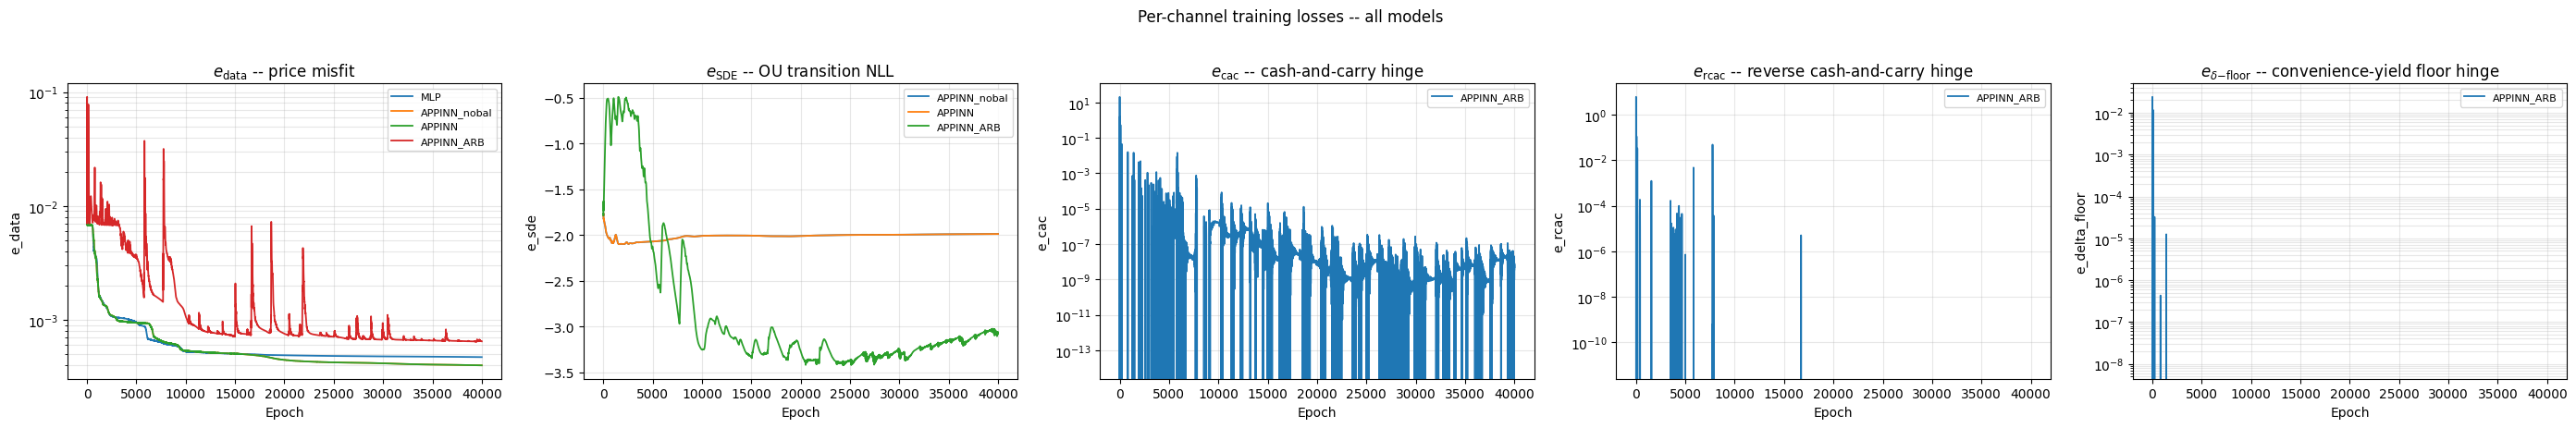

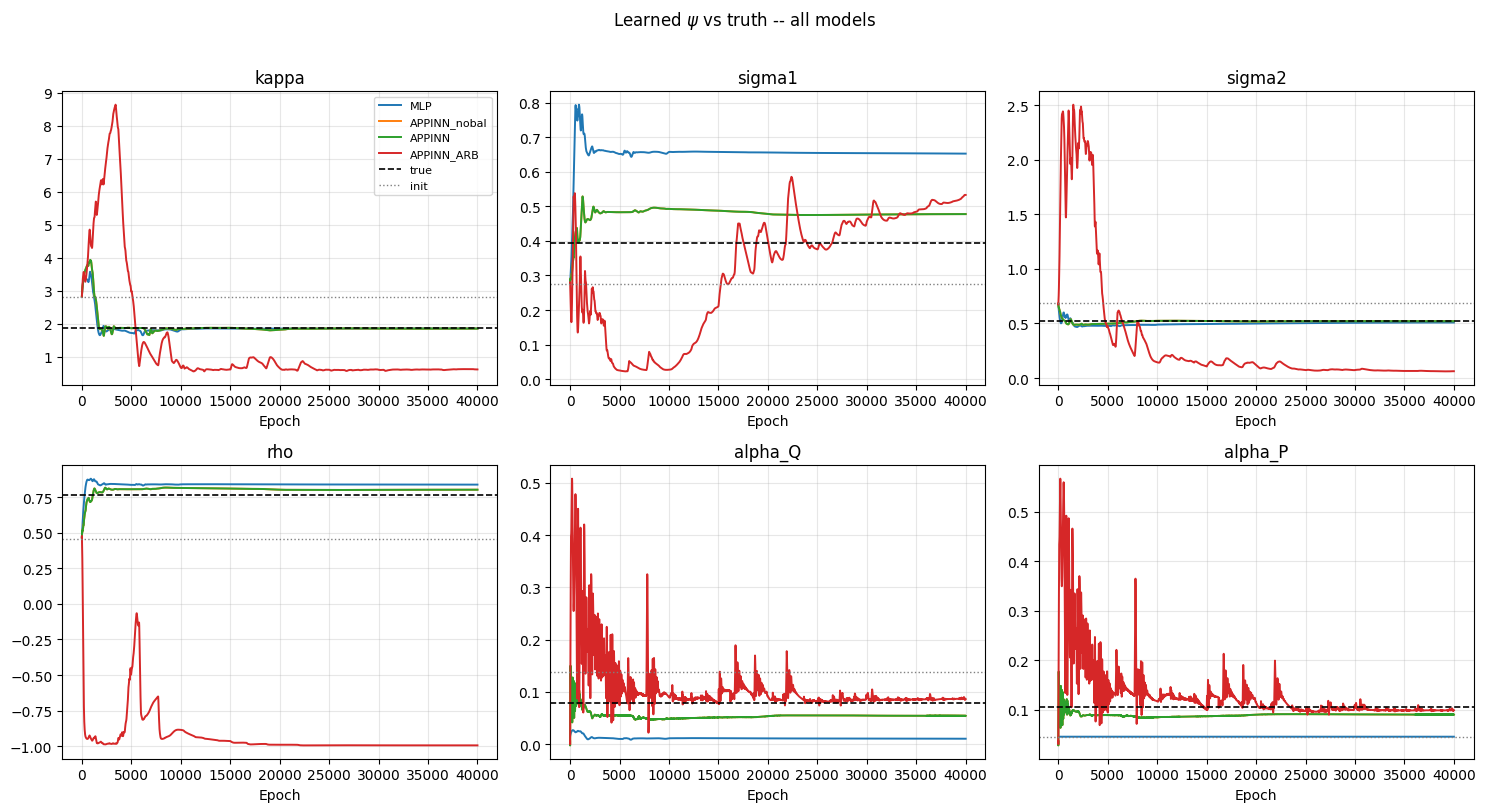

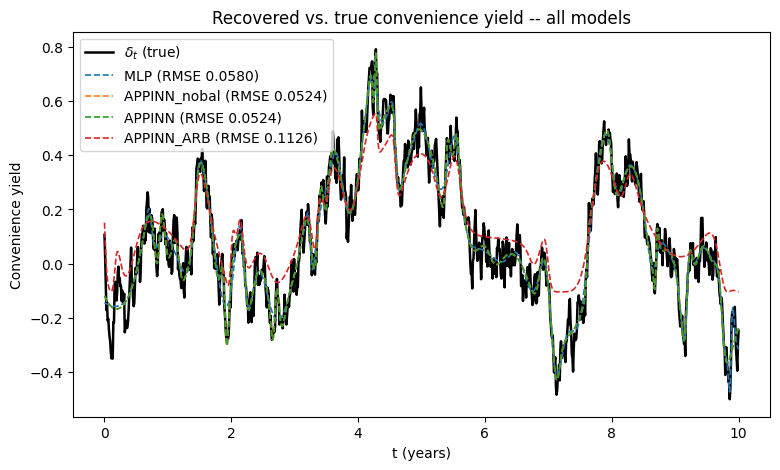

In [17]:
ORDER = ["kappa", "sigma1", "sigma2", "rho", "alpha_Q", "alpha_P"]


def _load_history(tag):
    # psi_snapshot is history[3], added once psi became a learned leaf
    with open(f'{_MC_OUTPUT_DIR}/results/results_{tag}.pkl', 'rb') as f:
        return pickle.load(f)['history']


def plot_training_history_composite(configs, histories, save_path=None):
    """Per-channel losses (unweighted means), one panel per channel, all models overlaid."""
    channels = ['e_data', 'e_sde', 'e_cac', 'e_rcac', 'e_delta_floor']
    yscale = {'e_data': 'log', 'e_sde': 'linear', 'e_cac': 'log', 'e_rcac': 'log', 'e_delta_floor': 'log'}
    titles = {
        'e_data': r'$e_{\mathrm{data}}$ -- price misfit',
        'e_sde':  r'$e_{\mathrm{SDE}}$ -- OU transition NLL',
        'e_cac':  r'$e_{\mathrm{cac}}$ -- cash-and-carry hinge',
        'e_rcac': r'$e_{\mathrm{rcac}}$ -- reverse cash-and-carry hinge',
        'e_delta_floor': r'$e_{\delta\mathrm{-floor}}$ -- convenience-yield floor hinge',
    }
    runs = {}
    for config in configs:
        tag = run_tag(config)
        hist = histories[tag]
        epochs  = [h[0] for h in hist]
        metrics = [h[2] for h in hist]
        series  = {k: [m[k] for m in metrics] for k in metrics[0]}
        runs[tag] = (epochs, series, set(init_l_ws[config.loss_str]))

    fig, axes = plt.subplots(1, len(channels), figsize=(28, 4.5))
    for ax, ch in zip(axes, channels):
        for tag, (epochs, series, trained) in runs.items():
            if ch in trained and ch in series:
                ax.plot(epochs, series[ch], lw=1.3, label=tag)
        ax.set_xlabel('Epoch'); ax.set_ylabel(ch); ax.set_yscale(yscale[ch])
        ax.set_title(titles[ch]); ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=8)
    fig.suptitle('Per-channel training losses -- all models', y=1.02)
    fig.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show(); plt.close()


def plot_psi_trajectories(configs, histories, save_path=None):
    """Learned psi vs truth over training, one panel per parameter."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, p in zip(axes.ravel(), ORDER):
        for config in configs:
            tag = run_tag(config)
            hist = histories[tag]
            ax.plot([h[0] for h in hist], [h[3][p] for h in hist], lw=1.4, label=tag)
        ax.axhline(PSI_TRUE[p], color='black', ls='--', lw=1.2, label='true')
        ax.axhline(PSI_INIT[p], color='grey', ls=':', lw=1.0, label='init')
        ax.set_title(p); ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)
        if p == ORDER[0]:
            ax.legend(fontsize=8)
    fig.suptitle(r'Learned $\psi$ vs truth -- all models', y=1.01)
    fig.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show(); plt.close()


def print_psi_table(configs, histories):
    """Recovered psi vs true/init for each model (final epoch)."""
    tags = [run_tag(c) for c in configs]
    finals = {tag: histories[tag][-1][3] for tag in tags}
    head = f"{'param':>8} | {'true':>9} | {'init':>9} | " + " | ".join(f"{t:>9}" for t in tags)
    print(head); print('-' * len(head))
    for p in ORDER:
        row = f"{p:>8} | {PSI_TRUE[p]:9.4f} | {PSI_INIT[p]:9.4f} | " + \
              " | ".join(f"{finals[t][p]:9.4f}" for t in tags)
        print(row)


def plot_delta_recovery_composite(fns_by_tag, t, delta_true, save_path=None):
    """Overlay recovered delta_hat_phi(t) for all models vs the true (eval-only) path."""
    fig, ax = plt.subplots(1, 1, figsize=(9, 5))
    ax.plot(t, delta_true, color='black', lw=1.8, label=r'$\delta_t$ (true)')
    for tag, fns in fns_by_tag.items():
        _, delta_hat_fn, _ = fns
        delta_hat = vmap(delta_hat_fn)(t)
        rmse = float(jnp.sqrt(jnp.mean((delta_hat - delta_true) ** 2)))
        ax.plot(t, delta_hat, lw=1.2, ls='--', label=f'{tag} (RMSE {rmse:.4f})')
    ax.set_xlabel('t (years)'); ax.set_ylabel('Convenience yield'); ax.legend()
    ax.set_title('Recovered vs. true convenience yield -- all models')
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show(); plt.close()


# load each results pickle exactly once, reused by all three functions below
histories = {run_tag(c): _load_history(run_tag(c)) for c in configs}

print("Recovered psi vs true/init (final epoch):")
print_psi_table(configs, histories)

# Model comparison across loss-configuration variants is still in flux (this is where
# ACPINN/DCPINN naming has churned before -- see docs/project_summary.md). Render inline
# only, don't persist to figures/pinn/ -- the finalized comparison figures live in
# scripts/figures/make_pinn_figures.py once a model is chosen as the thesis result.
plot_training_history_composite(configs, histories)
plot_psi_trajectories(configs, histories)
plot_delta_recovery_composite(fns_by_tag, t_train, delta_true)

### Multi-Path Verification for MC-simulated data only

In [18]:
# taus/t_train/p_Q/kappa_P/alpha_P/sigma2_P aren't indexed by path (confirmed in
# get_data_mc) -- load the pickle once here and slice per path_id directly,
# instead of calling get_data_mc() 20x (each call reopens and unpickles the
# entire multi-path file just to read out one path's S/log_F_obs/delta_true).
with open(_MC_DATA_PATH, "rb") as f:
    _mc_data_all = pickle.load(f)

results = []

for path_id in range(20):
    # Loop-local names (audit fix): the previous version reassigned the shared globals
    # S_train/log_F_obs_train/delta_true/data on every iteration and never restored them,
    # so after this cell ran they were left pointing at path 19 instead of path 0's data
    # cell values (data cell) -- harmless today since nothing downstream reads those
    # globals by name before the real-WTI section explicitly overwrites them, but a
    # landmine for any cell inserted later. Using suffixed names here keeps the module-
    # level globals pinned to path_id=0 for the rest of the notebook.
    S_train_i = _mc_data_all["S"][path_id]
    log_F_obs_train_i = _mc_data_all["log_F_obs"][path_id]
    delta_true_i = _mc_data_all["delta_true"][path_id]
    data_i = (t_train, S_train_i, log_F_obs_train_i)

    # save_checkpoint=False: this reuses config_APPINN, whose run_tag() is "APPINN" --
    # the same checkpoint dir the main single-path run above already wrote to. Saving
    # here on every one of the 20 repeats would overwrite that run's weights with
    # whichever path happened to run last.
    fns, hist_loss = calibration(config_APPINN, data_i, hp=adam_hp, save_checkpoint=False)
    _, metrics = error(fns, data_i)

    _, delta_hat_fn, gsp = fns
    delta_hat = vmap(delta_hat_fn)(t_train)
    delta_rmse = float(jnp.sqrt(jnp.mean((delta_hat - delta_true_i) ** 2)))

    # recovered psi for this path, straight off gsp -- no need to reload history
    psi_hat = psi_dict(gsp["p_Q"], gsp["alpha_P"])

    results.append({
        "path_id": path_id,
        "psi_hat": psi_hat,
        "delta_rmse": delta_rmse,
        "metrics": {k: float(v) for k, v in metrics.items()},
        # stored per-path so the composite plot below doesn't need to re-run calibration --
        # each path has its OWN delta_true/delta_hat, not a shared one
        "delta_true": np.asarray(delta_true_i),
        "delta_hat": np.asarray(delta_hat),
    })

    print(f"path {path_id:2d}  delta_rmse {delta_rmse:.4f}  "
          f"kappa_hat {psi_hat['kappa']:.3f}  alpha_P_hat {psi_hat['alpha_P']:.3f}")

# persist the full per-path arrays (not just the printed summary) so figure
# scripts can rebuild the validation plot without re-running 20 calibrations.
os.makedirs(f'{_MC_OUTPUT_DIR}/results', exist_ok=True)
with open(f'{_MC_OUTPUT_DIR}/results/path_repeat.pkl', 'wb') as f:
    pickle.dump({"results": results, "t_train": np.asarray(t_train), "psi_true": PSI_TRUE}, f)

APPINN calibration------>


------> completed in 49.63 seconds
path  0  delta_rmse 0.0524  kappa_hat 1.852  alpha_P_hat 0.091
APPINN calibration------>


------> completed in 48.03 seconds


path  1  delta_rmse 0.0576  kappa_hat 1.812  alpha_P_hat 0.085
APPINN calibration------>


------> completed in 47.55 seconds
path  2  delta_rmse 0.0507  kappa_hat 1.861  alpha_P_hat 0.207
APPINN calibration------>


...

------> completed in 41.80 seconds
path 15  delta_rmse 0.0528  kappa_hat 1.892  alpha_P_hat 0.081
APPINN calibration------>


------> completed in 42.08 seconds
path 16  delta_rmse 0.0505  kappa_hat 1.841  alpha_P_hat 0.234
APPINN calibration------>


------> completed in 42.12 seconds
path 17  delta_rmse 0.0470  kappa_hat 1.835  alpha_P_hat 0.122
APPINN calibration------>


------> completed in 41.49 seconds
path 18  delta_rmse 0.0508  kappa_hat 1.825  alpha_P_hat -0.004
APPINN calibration------>


------> completed in 41.93 seconds
path 19  delta_rmse 0.0498  kappa_hat 1.821  alpha_P_hat 0.105


In [19]:
rmse_arr = np.array([r["delta_rmse"] for r in results])
print(f"delta RMSE across {len(results)} paths: mean {rmse_arr.mean():.4f}  std {rmse_arr.std():.4f}\n")

print(f"{'param':>8} | {'true':>9} | {'mean_hat':>9} | {'std_hat':>9}")
for p in ORDER:
    vals = np.array([r["psi_hat"][p] for r in results])
    print(f"{p:>8} | {PSI_TRUE[p]:9.4f} | {vals.mean():9.4f} | {vals.std():9.4f}")

delta RMSE across 20 paths: mean 0.0515  std 0.0029

   param |      true |  mean_hat |   std_hat
   kappa |    1.8760 |    1.8444 |    0.0300
  sigma1 |    0.3930 |    0.5504 |    0.2679
  sigma2 |    0.5270 |    0.5465 |    0.0480
     rho |    0.7660 |    0.7019 |    0.3531
 alpha_Q |    0.0779 |    0.0334 |    0.0923
 alpha_P |    0.1060 |    0.0719 |    0.0920


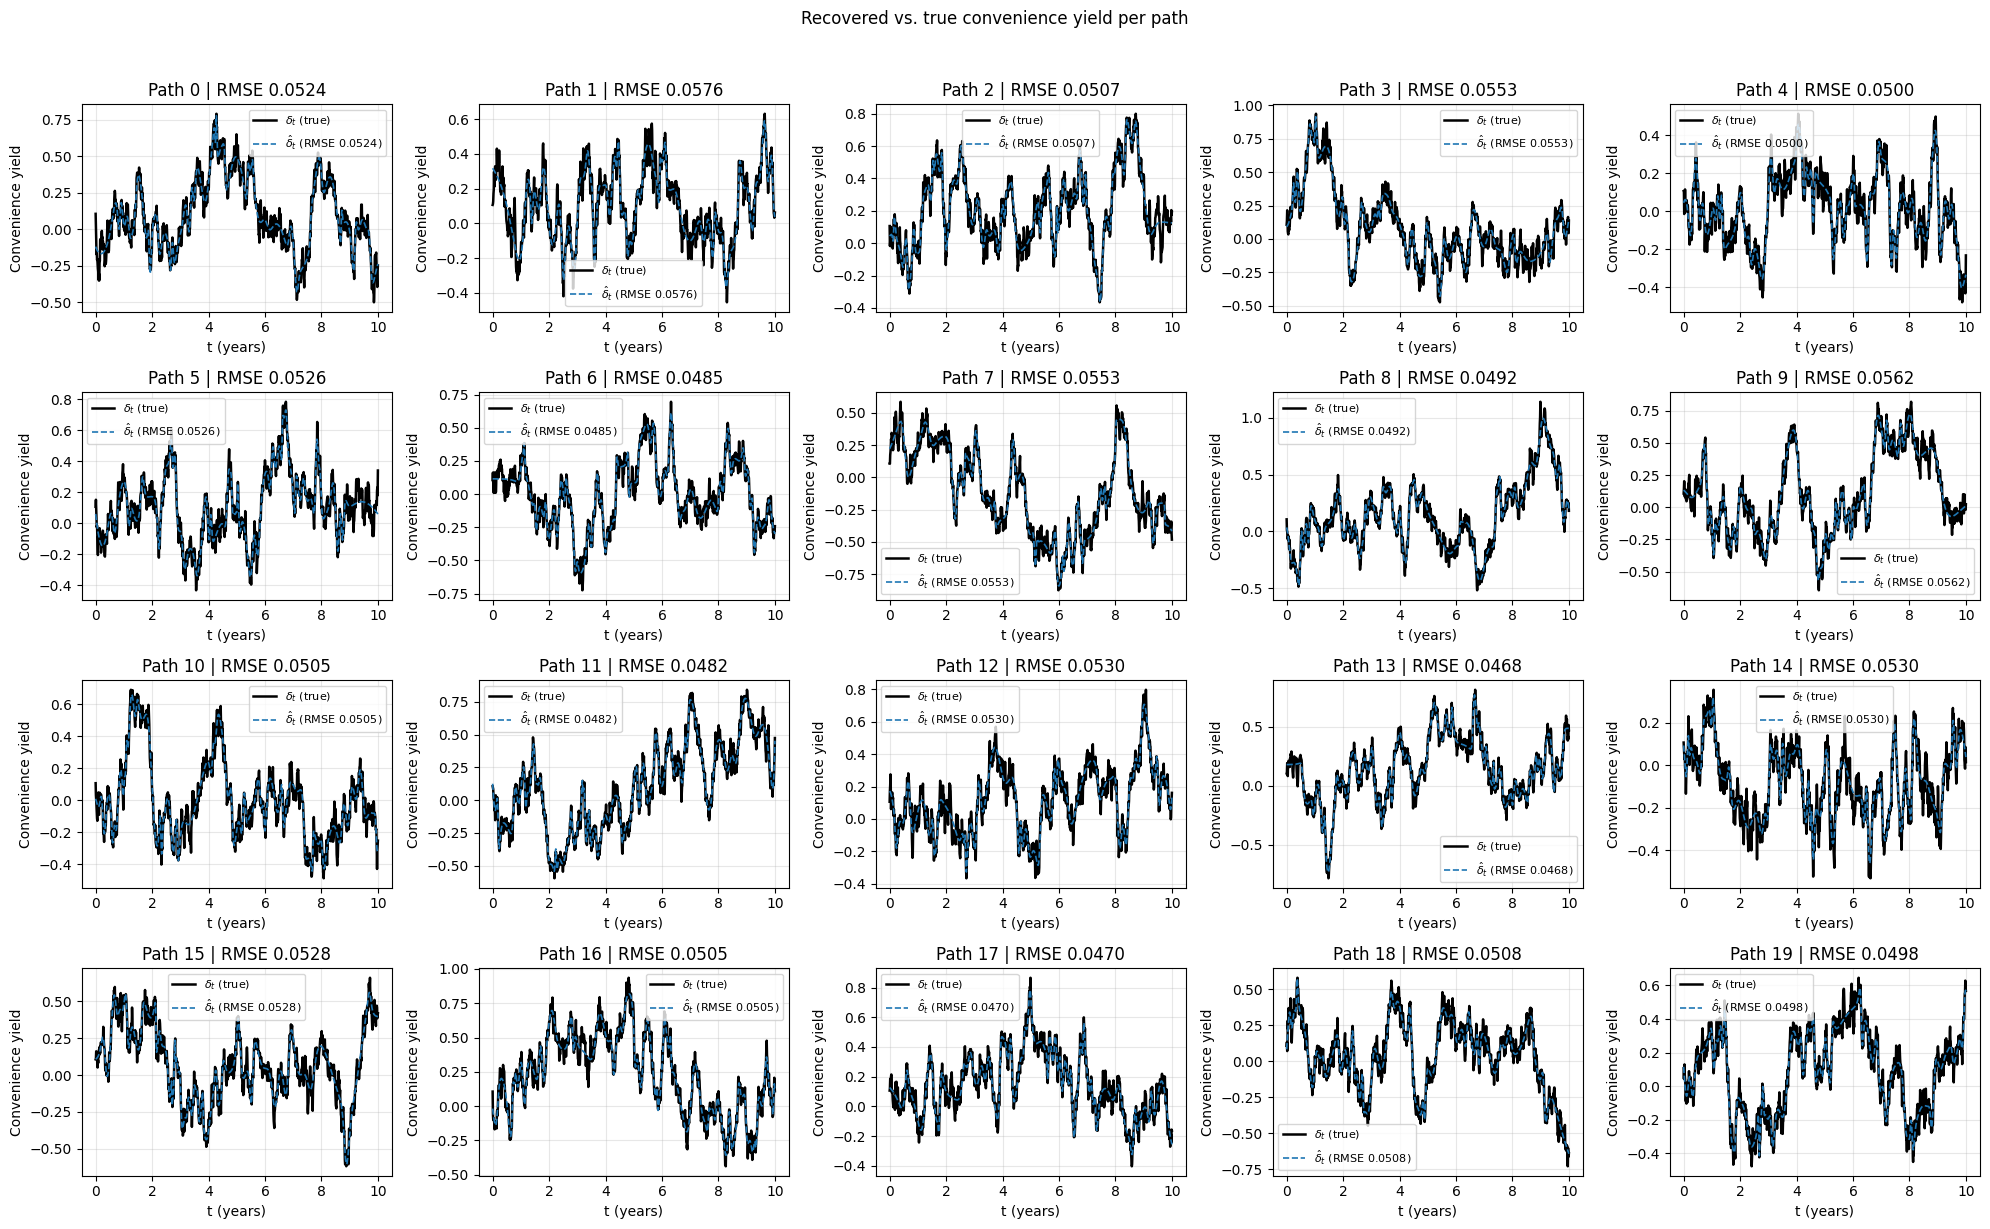

In [20]:
# plot delta recovery for each path - composite figure with subplots for each path
def plot_delta_recovery_per_path(results, t_train, save_path=None):
    n_paths = len(results)
    n_cols = 5
    n_rows = (n_paths + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
    axes = axes.flatten()

    for i, result in enumerate(results):
        path_id = result["path_id"]
        delta_rmse = result["delta_rmse"]

        ax = axes[i]
        # each path plotted against its OWN true/recovered delta, not a shared one
        ax.plot(t_train, result["delta_true"], color='black', lw=1.8, label=r'$\delta_t$ (true)')
        ax.plot(t_train, result["delta_hat"], lw=1.2, ls='--', label=f'$\hat{{\delta}}_t$ (RMSE {delta_rmse:.4f})')
        ax.set_title(f'Path {path_id} | RMSE {delta_rmse:.4f}')
        ax.set_xlabel('t (years)')
        ax.set_ylabel('Convenience yield')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle('Recovered vs. true convenience yield per path', y=1.02)
    fig.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show(); plt.close()


plot_delta_recovery_per_path(results, t_train)  # synthetic-data ablation, inline only -- not a thesis figure

### Real WTI Data Calibration — Benchmarked Against the Kalman Filter

Real WTI data has no `delta_true`/`PSI_TRUE` — `delta_t` is genuinely latent in reality, so there is no ground truth to score against, unlike every MC-simulated section above. The benchmark instead is the classical **Kalman filter** (`notebooks/kalman_filter.ipynb`, Krul 2008 ch.4 MLE) — an independent, non-PINN estimate of the same latent state from the same WTI panel, already fit and saved at `data/output/kalman/results/results_kalman.pkl`.

That fit also supplies real values for two things this notebook previously had to guess at: `PSI_INIT` (Schwartz-1997-style literature guesses replaced by the Kalman's own converged psi) and `LAMBDA2_FIXED` (the Kalman's own MLE-fitted `lam` ≈ 0.44 — the actual "historical estimate" the fixed-risk-premium design always wanted, not a placeholder).

Reuses `calibration()`/`error()`/`psi_dict()`/`run_tag()` unchanged — they were always source-agnostic (data-cell comment above). `save_checkpoint=False`: this is a benchmark run, not persisted alongside the MC-simulated results (`_MC_OUTPUT_DIR`) since it would collide with them under the same `run_tag()`s.

**Important finding from getting this running**: an earlier standalone version of this same real-data test (before folding in here) diverged completely on `APPINN_ARB` — loss exploding, κ running away to 25+, ρ pinned at the tanh boundary — because that quick script had dropped the WamOL loss-balancer for speed. With a low starting κ (0.43, from the Kalman fit) `B(τ)≈-1/κ≈-2.3` amplifies price-space gradients into the path net heavily; without the balancer equalizing channel gradient magnitudes, that snowballed into a runaway. The notebook's actual `calibration()` (above) already has the balancer, so this isn't an issue here — flagged so the reason isn't a mystery if anyone reruns the standalone version.

In [12]:
# Real WTI data has no delta_true/PSI_TRUE -- the Kalman filter (kalman_filter.ipynb,
# Krul 2008 ch.4 MLE) is the benchmark instead: an independent classical estimate of
# the same latent state from the same panel. Its own fitted psi also gives PSI_INIT/
# LAMBDA2_FIXED a real "historical estimate" instead of literature-guess numbers.
_KALMAN_RESULTS_PATH = "../data/output/kalman/results/results_kalman.pkl"
with open(_KALMAN_RESULTS_PATH, "rb") as f:
    kf = pickle.load(f)

wti_dates, t_train, S_train, taus, log_F_obs_train, _, _, _, _, _, _ = get_data_wti()
data = (t_train, S_train, log_F_obs_train)
T_SCALE = float(t_train[-1])

# Overrides the MC-section globals of the same name (data cell / loss-terms cell) --
# calibration()/error()/make_fns() read these by name at call time, not by value at
# definition time, so reassigning here is enough to redirect all of them at real data.
PSI_INIT = {k: float(kf["psi_hat"][k]) for k in ["kappa", "sigma1", "sigma2", "rho", "alpha_P"]}
LAMBDA2_FIXED = float(kf["psi_hat"]["lam"])
STORAGE_COST_U, DELTA_MAX = guardrail_arrays(len(t_train))

print("t_train        ", t_train.shape, f"date range [{wti_dates[0]}, {wti_dates[-1]}]  T_SCALE={T_SCALE:.2f}yr")
print("PSI_INIT (Kalman-filter-fitted)", {k: round(v, 4) for k, v in PSI_INIT.items()})
print("LAMBDA2_FIXED (Kalman-fitted lam)", round(LAMBDA2_FIXED, 4))


t_train         (2770,) date range [2015-01-02T00:00:00.000000, 2026-02-19T00:00:00.000000]  T_SCALE=11.14yr
is_crisis       (2770,) 515 crisis-flagged rows
PSI_INIT (Kalman-filter-fitted) {'kappa': 0.4257, 'sigma1': 0.4397, 'sigma2': 0.1726, 'rho': 0.8883, 'alpha_P': 0.1007}
LAMBDA2_FIXED (Kalman-fitted lam) 0.439


In [13]:
config_MLP_real, _, config_APPINN_real, config_APPINN_ARB_real = make_variant_configs(num_epochs=40000)

real_results = {}
for cfg in [config_MLP_real, config_APPINN_real, config_APPINN_ARB_real]:
    fns, hist_loss = calibration(cfg, data, save_checkpoint=False)
    err, metrics = error(fns, data)
    _, delta_hat_fn, gsp = fns
    real_results[run_tag(cfg)] = {
        "psi": psi_dict(gsp["p_Q"], gsp["alpha_P"]),
        "delta_hat": np.asarray(vmap(delta_hat_fn)(t_train)),
        "metrics": {k: float(v) for k, v in metrics.items()},
    }
    print(f"{run_tag(cfg)} metrics:", {k: round(v, 5) for k, v in real_results[run_tag(cfg)]["metrics"].items()})

W0802 12:20:47.925285 31683617 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


MLP calibration------>


------> completed in 69.29 seconds


MLP metrics: {'e_data': 0.00059, 'e_sde': -2.40997, 'e_cac': 0.55198, 'e_rcac': 0.0, 'e_delta_floor': 0.00422}
APPINN calibration------>


------> completed in 117.90 seconds


APPINN metrics: {'e_data': 0.0006, 'e_sde': -2.38236, 'e_cac': 0.55423, 'e_rcac': 0.0, 'e_delta_floor': 0.00437}


APPINN_ARB calibration------>


------> completed in 127.08 seconds


APPINN_ARB metrics: {'e_data': 0.00221, 'e_sde': -4.4071, 'e_cac': 0.0, 'e_rcac': 0.0, 'e_delta_floor': 0.0}



PSI vs KALMAN FILTER (the real-data baseline -- Krul 2008 MLE, same WTI panel)
   param |     kalman |          MLP |       APPINN |   APPINN_ARB
------------------------------------------------------------------
   kappa |     0.4257 |       1.0623 |       1.0712 |       0.0025
  sigma1 |     0.4397 |       0.6346 |       0.7769 |       2.0120
  sigma2 |     0.1726 |       0.5870 |       0.5902 |       0.0215
     rho |     0.8883 |       0.9921 |       0.9690 |      -0.9922
 alpha_Q |    -0.0773 |      -0.1419 |      -0.2082 |       1.1467
 alpha_P |     0.1007 |       0.1007 |       0.0337 |       4.9816

DELTA_HAT vs KALMAN FILTER (common dates -- the real comparison, no ground truth exists)


common dates: 2769  (KF 2769, PINN 2770)
Kalman delta_hat  mean +0.0395  std 0.1078  min -0.2925  max +0.2320
MLP            mean +0.0113  std 0.1763  min -1.2694  max +0.3187  | vs KF: corr +0.8812  RMSE 0.1001
APPINN         mean +0.0100  std 0.1771  min -1.2960  max +0.3918  | vs KF: corr +0.8779  RMSE 0.1016
APPINN_ARB     mean +0.0962  std 0.0783  min -0.2576  max +0.2491  | vs KF: corr +0.9093  RMSE 0.0749


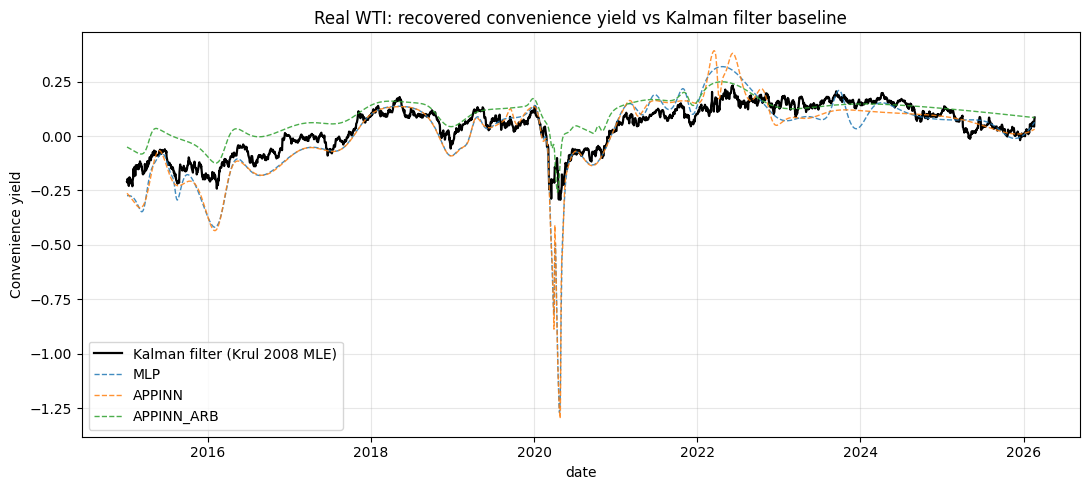

In [14]:
print("\n" + "=" * 90)
print("PSI vs KALMAN FILTER (the real-data baseline -- Krul 2008 MLE, same WTI panel)")
print("=" * 90)
head = f"{'param':>8} | {'kalman':>10} | " + " | ".join(f"{t:>12}" for t in real_results)
print(head); print("-" * len(head))
for p in ["kappa", "sigma1", "sigma2", "rho", "alpha_Q", "alpha_P"]:
    row = f"{p:>8} | {kf['psi_hat'][p]:10.4f} | " + " | ".join(f"{real_results[t]['psi'][p]:12.4f}" for t in real_results)
    print(row)

print("\n" + "=" * 90)
print("DELTA_HAT vs KALMAN FILTER (common dates -- the real comparison, no ground truth exists)")
print("=" * 90)
kf_dates_idx = pd.DatetimeIndex(kf["dates"])
wti_dates_idx = pd.DatetimeIndex(wti_dates)
common = kf_dates_idx.intersection(wti_dates_idx)
kf_pos = kf_dates_idx.get_indexer(common)
wti_pos = wti_dates_idx.get_indexer(common)
kf_delta_common = kf["delta_hat"][kf_pos]
print(f"common dates: {len(common)}  (KF {len(kf_dates_idx)}, PINN {len(wti_dates_idx)})")
print(f"Kalman delta_hat  mean {kf_delta_common.mean():+.4f}  std {kf_delta_common.std():.4f}  "
      f"min {kf_delta_common.min():+.4f}  max {kf_delta_common.max():+.4f}")
for tag, r in real_results.items():
    d = r["delta_hat"][wti_pos]
    corr = float(np.corrcoef(d, kf_delta_common)[0, 1])
    rmse = float(np.sqrt(np.mean((d - kf_delta_common) ** 2)))
    print(f"{tag:14s} mean {d.mean():+.4f}  std {d.std():.4f}  min {d.min():+.4f}  max {d.max():+.4f}  "
          f"| vs KF: corr {corr:+.4f}  RMSE {rmse:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(11, 5))
ax.plot(common, kf_delta_common, color="black", lw=1.6, label="Kalman filter (Krul 2008 MLE)")
for tag, r in real_results.items():
    ax.plot(common, r["delta_hat"][wti_pos], lw=1.0, ls="--", alpha=0.85, label=tag)
ax.set_xlabel("date"); ax.set_ylabel("Convenience yield"); ax.legend()
ax.set_title("Real WTI: recovered convenience yield vs Kalman filter baseline")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show(); plt.close()

In [15]:
# Persist real-data results, mirroring the MC section's on-disk convention
# (data/output/real_data/results/results_<tag>.pkl, one file per variant) so
# downstream figure scripts read from disk rather than re-running calibration.
_REAL_OUTPUT_DIR = "../data/output/real_data"
os.makedirs(f'{_REAL_OUTPUT_DIR}/results', exist_ok=True)
for tag, r in real_results.items():
    with open(f'{_REAL_OUTPUT_DIR}/results/results_{tag}.pkl', 'wb') as f:
        pickle.dump({
            "psi": r["psi"],
            "delta_hat": r["delta_hat"],
            "metrics": r["metrics"],
            "dates": wti_dates,
            "t_train": np.asarray(t_train),
            "taus": np.asarray(taus),
        }, f)
print(f"wrote {len(real_results)} real-data result files to {_REAL_OUTPUT_DIR}/results/")


wrote 3 real-data result files to ../data/output/real_data/results/


### Temporal Holdout — Out-of-Sample Pricing Generalization

Not a classical ML train/test split: there is no observable `delta_t` to hold out and score against (it's latent by construction). "Generalization" here means something more specific — whether the `psi` and path net fitted on early dates still price *observed futures* well on later dates the model never trained on.

This also directly stress-tests a limitation already named in `docs/mathematical_derivations-6.pdf` §12.3, rather than leaving it as a theoretical caveat: the path net is a plain function of `normalize_time(t)`, so evaluating it past its trained `[0, T_SCALE]` domain is neural extrapolation — "a new observation date extends the required domain of δ̂_φ beyond its trained support, where neural extrapolation is unreliable."

Split: train on dates before 2024-01-01, hold out 2024-01-01 onward (~19% of the panel, ~2.1 years). Reuses `calibration()`/`B_coeff`/`A_coeff` unchanged; overrides `data`/`T_SCALE`/`STORAGE_COST_U`/`DELTA_MAX` to the train-only subset the same way the real-WTI cell above overrode the MC-section globals — `PSI_INIT`/`LAMBDA2_FIXED` are left as the Kalman-fitted values from that cell. (`STORAGE_COST_U`/`DELTA_MAX` no longer depend on date at all since the crisis-regime switch was scrapped — see the loss-terms constants cell — so this override is just re-sizing them to the train-only date count.)

In [24]:
# See markdown above for why this isn't a classical ML train/test split.
HOLDOUT_CUTOFF = np.datetime64("2024-01-01")
train_mask = wti_dates < HOLDOUT_CUTOFF
test_mask = ~train_mask
print(f"train: {train_mask.sum()} dates (< {HOLDOUT_CUTOFF})  "
      f"test: {test_mask.sum()} dates ({100*test_mask.mean():.1f}% held out)")

# Full-range arrays preserved under _full names before data/T_SCALE/STORAGE_COST_U/
# DELTA_MAX (globals calibration()/error()/make_fns() read by name) get overridden to
# the train-only subset below.
t_train_full, S_train_full, log_F_obs_train_full = t_train, S_train, log_F_obs_train

t_train_ho = t_train_full[train_mask]
S_train_ho = S_train_full[train_mask]
log_F_obs_train_ho = log_F_obs_train_full[train_mask]
t_test_ho = t_train_full[test_mask]
S_test_ho = S_train_full[test_mask]
log_F_obs_test_ho = log_F_obs_train_full[test_mask]

data = (t_train_ho, S_train_ho, log_F_obs_train_ho)
T_SCALE = float(t_train_ho[-1])
STORAGE_COST_U, DELTA_MAX = guardrail_arrays(len(t_train_ho))
# PSI_INIT/LAMBDA2_FIXED unchanged -- still the Kalman-fitted values from the cell above.

# num_epochs=40000 explicitly -- matches the MC section (Run cell) and real-WTI section
# (audit fix: this call previously used make_variant_configs()'s bare 5000-epoch smoke-test
# default, silently undertraining the holdout comparison relative to the other two sections).
config_MLP_ho, _, config_APPINN_ho, config_APPINN_ARB_ho = make_variant_configs(num_epochs=40000)

ho_fns_by_tag = {}
for cfg in [config_MLP_ho, config_APPINN_ho, config_APPINN_ARB_ho]:
    fns, _ = calibration(cfg, data, save_checkpoint=False)
    ho_fns_by_tag[run_tag(cfg)] = fns


train: 2237 dates (< 2024-01-01)  test: 533 dates (19.2% held out)


MLP calibration------>


------> completed in 7.61 seconds
APPINN calibration------>


------> completed in 10.43 seconds
APPINN_ARB calibration------>


------> completed in 10.85 seconds


In [25]:
# Price-fit only (not the full error() dict): the point of this cell is out-of-sample
# PRICING generalization specifically, and error()'s e_cac/e_rcac/e_delta_floor would
# need STORAGE_COST_U/DELTA_MAX re-sliced to the test dates' shape for no real benefit
# here -- e_data is the metric this holdout is designed to test.
def price_rmse_and_path(fns, t_arr, S_arr, logF_arr):
    _, delta_hat_fn, gsp = fns
    p_Q = gsp["p_Q"]
    delta_hat = vmap(delta_hat_fn)(t_arr)

    def log_F_hat_fn(S, delta, tau):
        return jnp.log(S) + B_coeff(tau, p_Q.kappa) * delta + A_coeff(tau, p_Q)

    log_F_hat = vmap(lambda S, d: vmap(lambda tau: log_F_hat_fn(S, d, tau))(taus))(S_arr, delta_hat)
    rmse = float(jnp.sqrt(jnp.mean((log_F_hat - logF_arr) ** 2)))
    return rmse, np.asarray(delta_hat)

print(f"{'variant':>12} | {'in-sample RMSE':>15} | {'out-of-sample RMSE':>19} | {'ratio':>6}")
print("-" * 62)
ho_delta_full = {}
for tag, fns in ho_fns_by_tag.items():
    rmse_in, _ = price_rmse_and_path(fns, t_train_ho, S_train_ho, log_F_obs_train_ho)
    rmse_out, _ = price_rmse_and_path(fns, t_test_ho, S_test_ho, log_F_obs_test_ho)
    # full range (train+test) for the visualization below -- every test-period date
    # is neural extrapolation past T_SCALE (the train cutoff), by construction.
    _, delta_full = price_rmse_and_path(fns, t_train_full, S_train_full, log_F_obs_train_full)
    ho_delta_full[tag] = delta_full
    print(f"{tag:>12} | {rmse_in:15.5f} | {rmse_out:19.5f} | {rmse_out/rmse_in:6.2f}x")

     variant |  in-sample RMSE |  out-of-sample RMSE |  ratio
--------------------------------------------------------------


         MLP |         0.03097 |             0.06056 |   1.96x
      APPINN |         0.03668 |             0.03722 |   1.01x
  APPINN_ARB |         0.17239 |             0.06021 |   0.35x


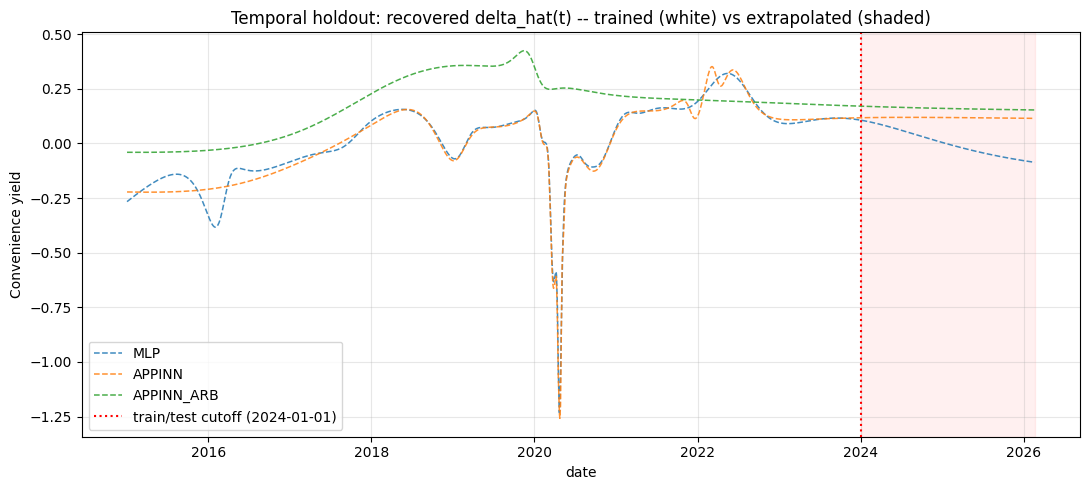

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(11, 5))
for tag, delta_full in ho_delta_full.items():
    ax.plot(wti_dates, delta_full, lw=1.1, ls="--", alpha=0.85, label=tag)
ax.axvline(HOLDOUT_CUTOFF, color="red", lw=1.5, ls=":", label=f"train/test cutoff ({HOLDOUT_CUTOFF})")
ax.axvspan(HOLDOUT_CUTOFF, wti_dates[-1], color="red", alpha=0.06)
ax.set_xlabel("date"); ax.set_ylabel("Convenience yield")
ax.set_title("Temporal holdout: recovered delta_hat(t) -- trained (white) vs extrapolated (shaded)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show(); plt.close()